In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt;

import numpy as np
import re
import glob


import seaborn as sns
from sklearn.metrics import r2_score
import sys
import pyemu
import flopy

from scipy.stats import pearsonr

In [2]:
pst = pyemu.Pst('../ies/peterson_tran.pst')

## Visualize Phi Convergence

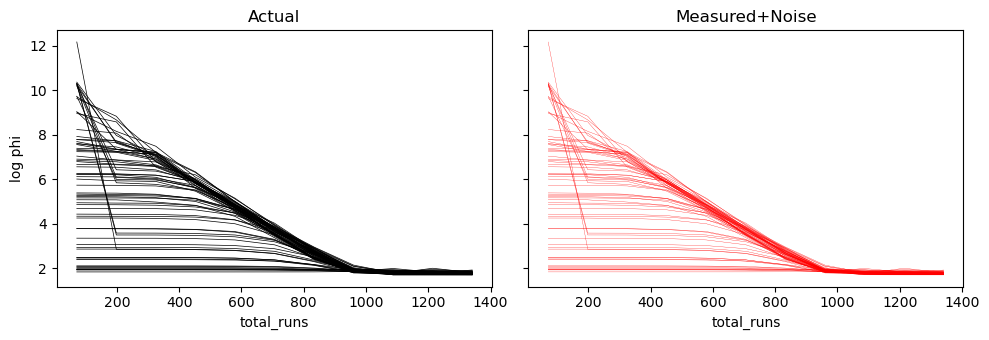

In [3]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
m_d= '../ies'
ax = axes[0]
phi = pd.read_csv(os.path.join(m_d,"peterson_tran.phi.actual.csv"),index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual')
ax.set_ylabel(r'log phi')
# right
ax = axes[-1]
phi = pd.read_csv(os.path.join(m_d,"peterson_tran.phi.meas.csv"),index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise')
fig.tight_layout()

## Read in Residuals Files

In [4]:
# Find all REI files
rei_files = sorted(glob.glob("../ies/peterson_tran.*.base.rei"))
# Read each file manually, skipping header lines
rei_list = []
for i, file in enumerate(rei_files):
    with open(file, "r") as f:
        lines = f.readlines()

    # Find the start of the data (skipping the header)
    for idx, line in enumerate(lines):
        if line.strip().startswith("Name"):
            start_idx = idx #+ 1
            break

    # Read the table portion
    data = pd.read_csv(file, delim_whitespace=True, skiprows=start_idx)
    data["iteration"] = i + 1  # Add iteration number
    rei_list.append(data)

# Concatenate all iterations into one DataFrame
rei_df = pd.concat(rei_list, ignore_index=True)

C:\Users\ipedraza\AppData\Local\Temp\ipykernel_3188\4074819138.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\ipedraza\AppData\Local\Temp\ipykernel_3188\4074819138.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\ipedraza\AppData\Local\Temp\ipykernel_3188\4074819138.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\ipedraza\AppData\Local\Temp\ipykernel_3188\4074819138.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\ipedraza\AppData\Local\Temp\ipykernel_3188\4074819138.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and wil

## Plot all PFAS on 1:1 Plot

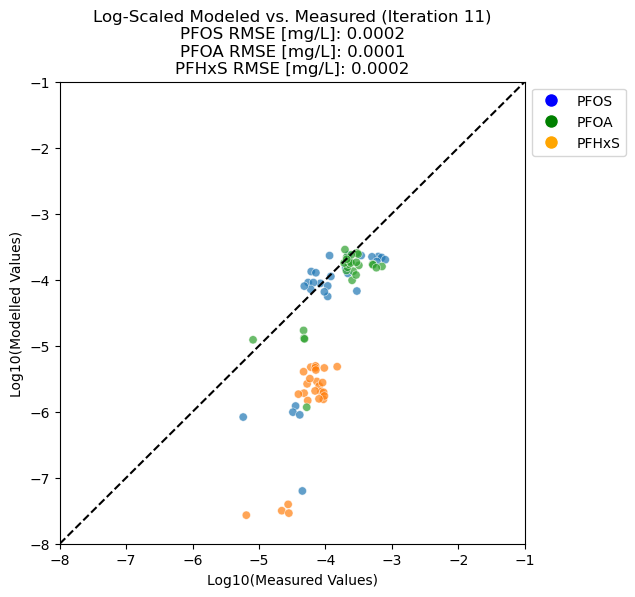

In [5]:
# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

rei_last["Measured"]= rei_last["Measured"] #* 1e6
rei_last["Modelled"]= rei_last["Modelled"] #* 1e6

# Apply log transformation (log10)
rei_last["log_measured"] = np.log10(rei_last["Measured"])
rei_last["log_modelled"] = np.log10(rei_last["Modelled"])

# Create a mapping for the observation names to colors (for _pfos, _pfoa, _pfhxs)
color_map = {
    "_pfos": "blue",  # Color for PFOS
    "_pfoa": "green",  # Color for PFOA
    "_pfhxs": "red",  # Color for PFHxS
}

# Add a new column to assign colors based on the observation name
def get_category(name):
    if "_pfos" in name:
        return "PFOS"
    elif "_pfoa" in name:
        return "PFOA"
    elif "_pfhxs" in name:
        return "PFHxS"
    else:
        return "Other"  # Default category if name doesn't match

rei_last["category"] = rei_last["Name"].apply(get_category)
rei_last["color"] = rei_last["category"].map({"PFOS": "blue", "PFOA": "green", "PFHxS": "red", "Other": "grey"})

# Calculate RMSE (Root Mean Squared Error) for each category
rmse_values = {}
for category in ["PFOS", "PFOA", "PFHxS"]:
    subset = rei_last[rei_last["category"] == category]
    if not subset.empty:
        rmse_values[category] = np.sqrt(((subset["Modelled"] - subset["Measured"]) ** 2).mean())
    else:
        rmse_values[category] = None  # Handle cases where a category might be missing

# Create the log-log plot with manually set colors
plt.figure(figsize=(6,6))
sns.scatterplot(data=rei_last, x="log_measured", y="log_modelled", hue="color", alpha=0.7, legend=None)

# Add a 1:1 line for reference
plt.plot([-8, 5],
         [-8, 5],
         color="black", linestyle="--", label="1:1 Line")

# Set equal axis limits (same limits for both axes)
min_val = min(rei_last["log_measured"].min(), rei_last["log_modelled"].min())
max_val = max(rei_last["log_measured"].max(), rei_last["log_modelled"].max())

plt.xlim(-8, -1)
plt.ylim(-8, -1)

# Labels and title
plt.xlabel("Log10(Measured Values)")
plt.ylabel("Log10(Modelled Values)")

# Format RMSE text for display
rmse_text = "\n".join([f"{key}{' RMSE [mg/L]'}: {value:.4f}" for key, value in rmse_values.items() if value is not None])

plt.title(f"Log-Scaled Modeled vs. Measured (Iteration {last_iter})\n{rmse_text}")

# Customize the legend manually with specific colors
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='PFOS'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='PFOA'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='PFHxS')
]
plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

# Show the plot
plt.show()


## Plot PFAS 1:1 on separate plots

In [34]:
# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

# Convert to ng/L
rei_last["Measured"] = rei_last["Measured"]
rei_last["Modelled"] = rei_last["Modelled"] 

In [35]:
rei_last.to_csv('../ies/modelled_v_measured.csv')

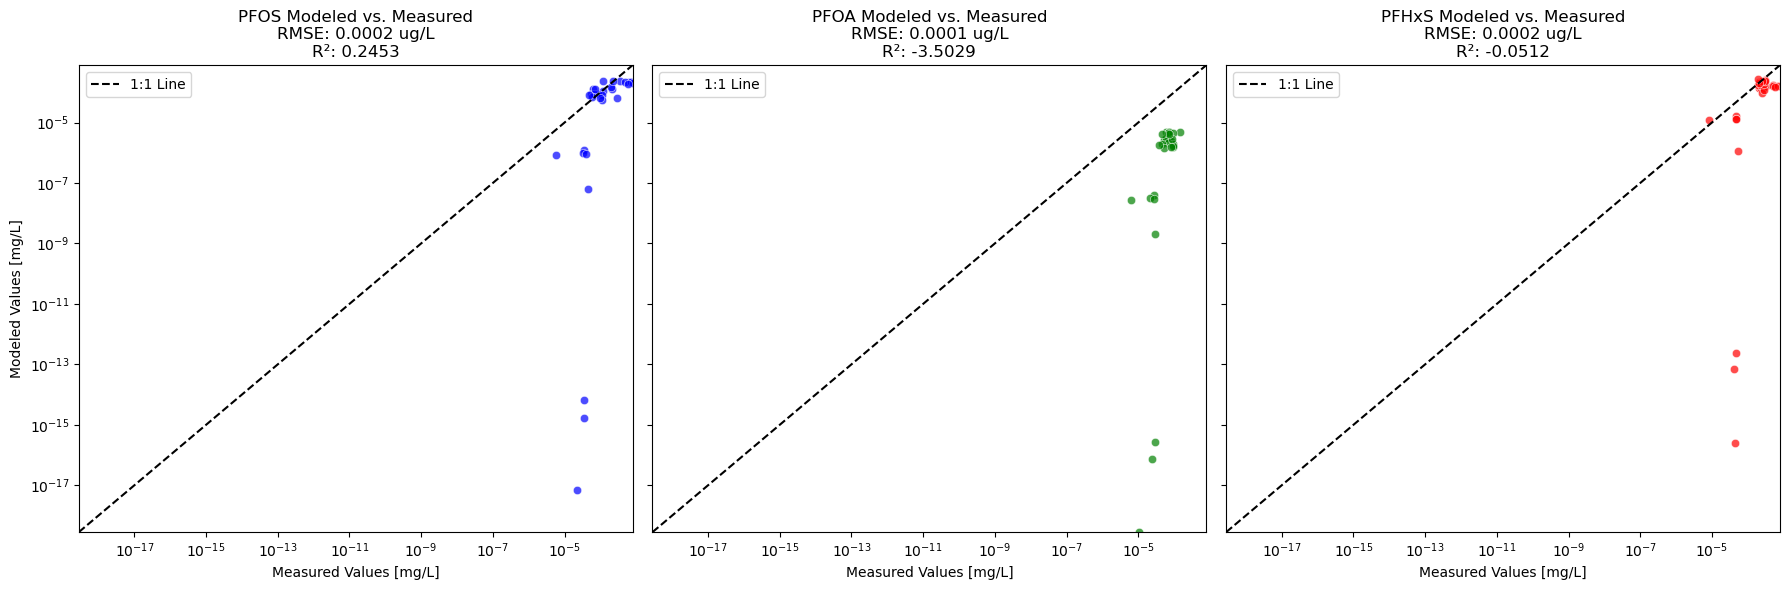

In [60]:
# Function to categorize PFAS type
def get_category(name):
    if "_pfos" in name:
        return "PFOS"
    elif "_pfoa" in name:
        return "PFOA"
    elif "_pfhxs" in name:
        return "PFHxS"
    else:
        return "Other"

# Assign categories and colors
rei_last["category"] = rei_last["Name"].apply(get_category)

# Calculate RMSE and R^2 for each category
rmse_values = {}
r2_values = {}
for category in ["PFOS", "PFOA", "PFHxS"]:
    subset = rei_last[rei_last["category"] == category]
    if not subset.empty:
        # RMSE Calculation
        rmse = np.sqrt(((subset["Modelled"] - subset["Measured"]) ** 2).mean())
        rmse_values[category] = rmse
        
        # R^2 Calculation
        r2 = r2_score(subset["Measured"], subset["Modelled"])
        r2_values[category] = r2

# Get min and max for axis limits
min_val = min(rei_last["Measured"].min(), rei_last["Modelled"].min())
max_val = max(rei_last["Measured"].max(), rei_last["Modelled"].max())

# Define category colors
category_colors = {"PFOS": "blue", "PFOA": "green", "PFHxS": "red"}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Iterate over categories and create individual scatter plots
for ax, category in zip(axes, ["PFOS", "PFOA", "PFHxS"]):
    subset = rei_last[rei_last["category"] == category]
    
    # Scatter plot
    sns.scatterplot(data=subset, x="Measured", y="Modelled", color=category_colors[category], alpha=0.7, ax=ax)
    
    # Add 1:1 reference line
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line", transform=ax.transData)

    # Set log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Set axis limits
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)


    # Labels and title
    ax.set_xlabel("Measured Values [mg/L]")
    ax.set_ylabel("Modeled Values [mg/L]")
    ax.set_title(f"{category} Modeled vs. Measured\nRMSE: {rmse_values.get(category, 'N/A'):.4f} ug/L\nR²: {r2_values.get(category, 'N/A'):.4f}")
    
    # Legend
    ax.legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

## Model Fit Statistics

In [37]:
from scipy.stats import pearsonr

In [56]:
def normalized_model_stats(obs, model):
    obs = np.array(obs)
    model = np.array(model)

    mae = np.mean(np.abs(obs - model))
    rmse = np.sqrt(np.mean((obs - model)**2))
    nrmse_mean = rmse / (np.mean(obs) )
    nrmse_range = rmse / (np.max(obs) - np.min(obs) )
    pbias = 100 * np.sum(model - obs) / (np.sum(obs) )

    r, _ = pearsonr(obs, model)
    beta = np.mean(model) / (np.mean(obs) )
    gamma = np.std(model) / (np.std(obs) )
    kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)

    d = 1 - np.sum((model - obs)**2) / (np.sum((np.abs(model - np.mean(obs)) + np.abs(obs - np.mean(obs)))**2) )

    nse = 1 - np.sum((obs - model)**2) / (np.sum((obs - np.mean(obs))**2) )
    
    r_squared = r**2  # R^2

    return {
        "RMSE": rmse,
        "nRMSE": nrmse_mean,
        "nRMSE": nrmse_range,
        "NSE": nse,
        "R^2": r_squared,
        "PBIAS": pbias,
        "KGE": kge,
        "Willmott d": d,
        "Pearson r": r
    }

In [57]:
subset = rei_last[rei_last["category"] == "PFOS"]
stats = normalized_model_stats(subset["Measured"], subset["Modelled"])
for k, v in stats.items():
    print(f"{k}: {v:.4f}")

RMSE: 0.0002
nRMSE: 0.2428
NSE: 0.2453
R^2: 0.5261
PBIAS: -45.9848
KGE: 0.1780
Willmott d: 0.6027
Pearson r: 0.7254


In [58]:
subset = rei_last[rei_last["category"] == "PFOA"]
stats = normalized_model_stats(subset["Measured"], subset["Modelled"])
for k, v in stats.items():
    print(f"{k}: {v:.4f}")

RMSE: 0.0001
nRMSE: 0.4592
NSE: -3.5029
R^2: 0.4205
PBIAS: -96.3323
KGE: -0.3941
Willmott d: 0.4126
Pearson r: 0.6485


In [59]:
subset = rei_last[rei_last["category"] == "PFHxS"]
stats = normalized_model_stats(subset["Measured"], subset["Modelled"])
for k, v in stats.items():
    print(f"{k}: {v:.4f}")

RMSE: 0.0002
nRMSE: 0.2436
NSE: -0.0512
R^2: 0.3158
PBIAS: -42.6741
KGE: 0.2212
Willmott d: 0.6262
Pearson r: 0.5620


## Remove Outliers

In [78]:
# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

rei_last = rei_last[~rei_last["Name"].str.startswith("brd_6_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("11960_opr_2_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("12425_opr_1_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("dle_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("gld_3_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("iris_3_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("well-1_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("well-3_")]
rei_last = rei_last[~rei_last["Name"].str.startswith("well-4_")]

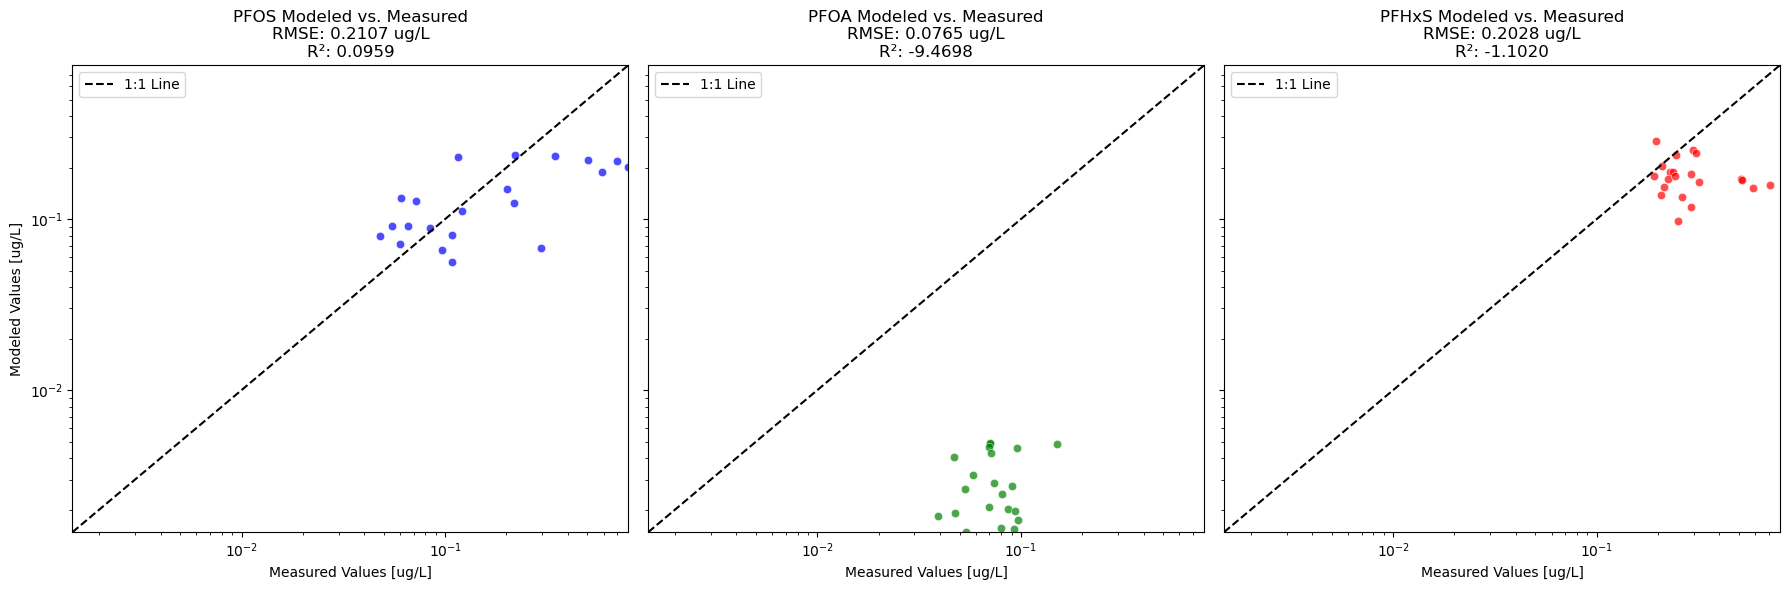

In [79]:
# Convert to ug/L
rei_last["Measured"] = rei_last["Measured"] * 1e3
rei_last["Modelled"] = rei_last["Modelled"] * 1e3

# Function to categorize PFAS type
def get_category(name):
    if "_pfos" in name:
        return "PFOS"
    elif "_pfoa" in name:
        return "PFOA"
    elif "_pfhxs" in name:
        return "PFHxS"
    else:
        return "Other"

# Assign categories and colors
rei_last["category"] = rei_last["Name"].apply(get_category)

# Calculate RMSE and R^2 for each category
rmse_values = {}
r2_values = {}
for category in ["PFOS", "PFOA", "PFHxS"]:
    subset = rei_last[rei_last["category"] == category]
    if not subset.empty:
        # RMSE Calculation
        rmse = np.sqrt(((subset["Modelled"] - subset["Measured"]) ** 2).mean())
        rmse_values[category] = rmse
        
        # R^2 Calculation
        r2 = r2_score(subset["Measured"], subset["Modelled"])
        r2_values[category] = r2

# Get min and max for axis limits
min_val = min(rei_last["Measured"].min(), rei_last["Modelled"].min())
max_val = max(rei_last["Measured"].max(), rei_last["Modelled"].max())

# Define category colors
category_colors = {"PFOS": "blue", "PFOA": "green", "PFHxS": "red"}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Iterate over categories and create individual scatter plots
for ax, category in zip(axes, ["PFOS", "PFOA", "PFHxS"]):
    subset = rei_last[rei_last["category"] == category]
    
    # Scatter plot
    sns.scatterplot(data=subset, x="Measured", y="Modelled", color=category_colors[category], alpha=0.7, ax=ax)
    
    # Add 1:1 reference line
    ax.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line", transform=ax.transData)

    # Set log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Set axis limits
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # Labels and title
    ax.set_xlabel("Measured Values [ug/L]")
    ax.set_ylabel("Modeled Values [ug/L]")
    ax.set_title(f"{category} Modeled vs. Measured\nRMSE: {rmse_values.get(category, 'N/A'):.4f} ug/L\nR²: {r2_values.get(category, 'N/A'):.4f}")
    
    # Legend
    ax.legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()